In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
plt.style.use('ggplot')

In [2]:
data_path = "/home/tahas44/Desktop/NYC-Taxi/datas/yellow_tripdata_2015-01.parquet"
df = pd.read_parquet(data_path)
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,1,2015-01-01 00:11:33,2015-01-01 00:16:48,1,1.0,1,N,41,166,1,5.7,0.5,0.5,1.40,0.0,0.0,8.40,None,None
1,1,2015-01-01 00:18:24,2015-01-01 00:24:20,1,0.9,1,N,166,238,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,None,None
2,1,2015-01-01 00:26:19,2015-01-01 00:41:06,1,3.5,1,N,238,162,1,13.2,0.5,0.5,2.90,0.0,0.0,17.40,None,None
3,1,2015-01-01 00:45:26,2015-01-01 00:53:20,1,2.1,1,N,162,263,1,8.2,0.5,0.5,2.37,0.0,0.0,11.87,None,None
4,1,2015-01-01 00:59:21,2015-01-01 01:05:24,1,1.0,1,N,236,141,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,None,None


### Step1: Data Understanding

In [3]:
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,1,2015-01-01 00:11:33,2015-01-01 00:16:48,1,1.0,1,N,41,166,1,5.7,0.5,0.5,1.40,0.0,0.0,8.40,None,None
1,1,2015-01-01 00:18:24,2015-01-01 00:24:20,1,0.9,1,N,166,238,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,None,None
2,1,2015-01-01 00:26:19,2015-01-01 00:41:06,1,3.5,1,N,238,162,1,13.2,0.5,0.5,2.90,0.0,0.0,17.40,None,None
3,1,2015-01-01 00:45:26,2015-01-01 00:53:20,1,2.1,1,N,162,263,1,8.2,0.5,0.5,2.37,0.0,0.0,11.87,None,None
4,1,2015-01-01 00:59:21,2015-01-01 01:05:24,1,1.0,1,N,236,141,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12741030,1,2015-01-31 23:21:42,2015-01-31 23:31:00,1,1.6,1,N,90,249,1,8.0,0.5,0.5,2.32,0.0,0.3,11.62,None,None
12741031,1,2015-01-31 23:42:43,2015-01-31 23:49:32,1,0.6,1,N,90,68,1,6.0,0.5,0.5,1.46,0.0,0.3,8.76,None,None
12741032,1,2015-01-31 23:55:16,2015-02-01 00:16:45,1,3.0,1,N,68,148,1,15.0,0.5,0.5,4.07,0.0,0.3,20.37,None,None
12741033,1,2015-01-31 23:20:53,2015-02-01 00:07:35,1,6.9,1,N,189,237,1,32.5,0.5,0.5,6.00,0.0,0.3,39.80,None,None


In [4]:
# data_path = "/home/tahas44/Desktop/NYC-Taxi/datas/yellow_tripdata_2015-02.parquet"
# df_1 = pd.read_parquet(data_path)
# df_1.head()

In [5]:
# df_1.columns

In [6]:
df[df["airport_fee"].notna()]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee


In [7]:
df[df["congestion_surcharge"].notna()]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee


In [8]:
df.drop(columns=["VendorID", "store_and_fwd_flag", "congestion_surcharge", "airport_fee"], inplace=True)

In [9]:
df.isna().sum() # ne kadar NA değerim var?

tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    3
total_amount             0
dtype: int64

Duplicate veri var mı?

In [10]:
df[df.duplicated()]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
495485,2015-01-02 12:45:27,2015-01-02 12:57:28,1,2.30,1,186,142,2,10.5,0.0,0.5,0.0,0.0,0.0,11.3
539505,2015-01-02 15:14:46,2015-01-02 15:16:17,1,0.00,1,264,264,2,2.1,0.0,0.5,0.0,0.0,0.3,2.9
542584,2015-01-02 15:14:46,2015-01-02 15:16:17,1,0.00,1,264,264,2,2.1,0.0,0.5,0.0,0.0,0.3,2.9
543221,2015-01-02 15:14:46,2015-01-02 15:16:17,1,0.00,1,264,264,2,2.1,0.0,0.5,0.0,0.0,0.3,2.9
545806,2015-01-02 15:14:46,2015-01-02 15:16:17,1,0.00,1,264,264,2,2.1,0.0,0.5,0.0,0.0,0.3,2.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5572083,2015-01-14 16:13:52,2015-01-14 16:14:01,1,0.00,1,264,264,2,2.0,0.0,0.5,0.0,0.0,0.3,2.8
5573035,2015-01-14 16:13:52,2015-01-14 16:14:01,1,0.00,1,264,264,2,2.0,0.0,0.5,0.0,0.0,0.3,2.8
5578913,2015-01-14 16:13:52,2015-01-14 16:14:01,1,0.00,1,264,264,2,2.0,0.0,0.5,0.0,0.0,0.3,2.8
5579596,2015-01-14 16:13:52,2015-01-14 16:14:01,1,0.00,1,264,264,2,2.0,0.0,0.5,0.0,0.0,0.3,2.8


In [11]:
# 229 tane duplicate veri ile karşılaştıktan sonra bunlardan kurtulmam gerek
df.drop_duplicates(inplace=True)

### Step2: Data Cleaning for Logic

Data Cleaning için 3 farklı metot belirledim ve bu metotlar right skewed veri dağılımı için uygun yöntemler. Bu yöntemler sonucunda elimdeki veriden çöpleri çıkaracağım.

### 2.1 fare_amount

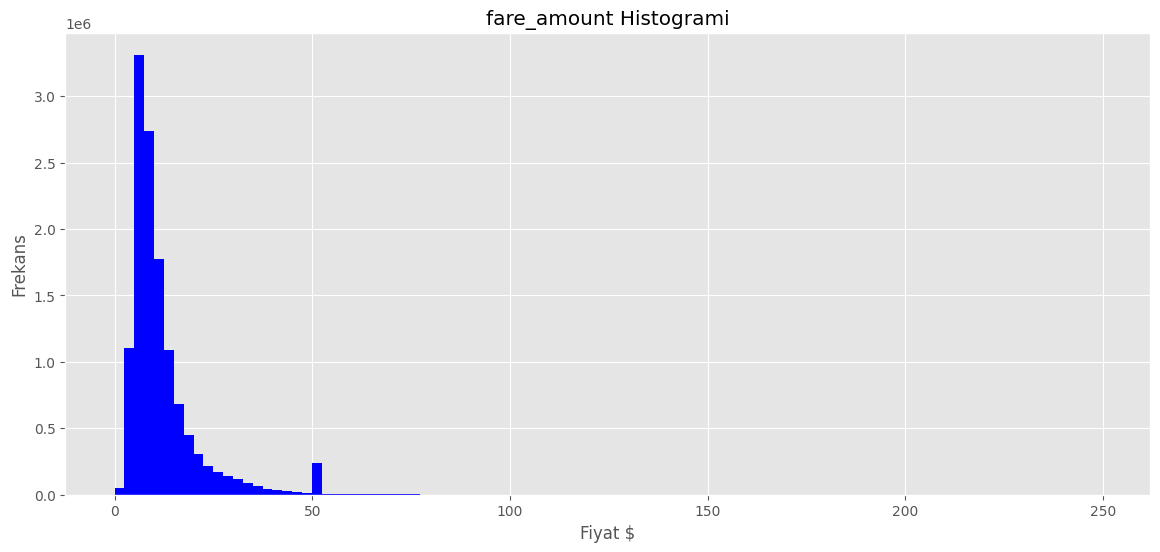

In [12]:
# Histogram ile oynama
plt.figure(figsize=(14,6))

df[(df["fare_amount"] < 250) & (df["fare_amount"] > 0)]["fare_amount"].plot(
    kind="hist", 
    bins=100, 
    color="blue"
)
plt.title("fare_amount Histogrami")
plt.xlabel("Fiyat $")
plt.ylabel("Frekans")
plt.show()

Grafikten elde edilen sonuç: fare_amount right skewed bir dağılım sergilemekte. Klasik Z score kullanılamaz!

IQR for fare_amount

In [33]:
indexes = df[df["fare_amount"] <= 0].index
df.drop(index=indexes, inplace=True)

In [34]:
# IQR dğerine ulaşmam için gerekli percintile hesapladım
Q1 = df["fare_amount"].quantile(0.25)
Q3 = df["fare_amount"].quantile(0.75)
IQR = Q3 - Q1

# sınırları bulayım
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")

Q1: 6.5, Q3: 13.5, IQR: 7.0
Lower Bound: -4.0, Upper Bound: 24.0


In [35]:
# Lets see the outliers
df[(df["fare_amount"] < lower_bound) | (df["fare_amount"] > upper_bound)]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,advanced_zscore_for_trip_distance,fare_amount_normalize,fare_per_distance
25,2015-01-01 00:44:34,2015-01-01 01:16:15,1,8.80,1,142,65,1,30.5,0.5,0.5,7.95,0.00,0.0,39.75,4.833917,3.449988,3.465909
43,2015-01-01 00:54:32,2015-01-01 01:30:34,1,7.64,1,236,256,1,28.0,0.5,0.5,5.70,0.00,0.3,35.00,4.271833,3.367296,3.664921
116,2015-01-01 00:54:26,2015-01-01 01:44:20,2,8.10,1,166,13,2,35.0,0.5,0.5,0.00,0.00,0.0,36.30,5.845667,3.583519,4.320988
132,2015-01-01 00:22:45,2015-01-01 00:48:57,1,6.80,1,79,166,1,24.5,0.5,0.5,5.15,0.00,0.0,30.95,3.484917,3.238678,3.602941
158,2015-01-01 00:24:12,2015-01-01 00:58:55,1,14.00,1,50,227,2,42.0,0.5,0.5,0.00,0.00,0.0,43.30,7.419500,3.761200,3.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12741009,2015-01-31 23:19:19,2015-02-01 00:15:08,3,13.00,1,163,220,1,49.5,0.5,0.5,15.00,4.88,0.3,70.68,9.105750,3.921973,3.807692
12741015,2015-01-31 23:27:10,2015-02-01 00:07:33,1,12.72,1,114,55,1,40.5,0.5,0.5,5.00,5.33,0.3,52.13,7.082250,3.725693,3.183962
12741025,2015-01-31 23:30:26,2015-02-01 00:30:05,1,13.75,1,148,89,2,46.5,0.5,0.5,0.00,5.33,0.3,53.13,8.431250,3.860730,3.381818
12741028,2015-01-31 23:36:46,2015-02-01 00:13:32,1,8.10,1,239,129,2,30.0,0.5,0.5,0.00,0.00,0.3,31.30,4.721500,3.433987,3.703704


İnceleme: IQR methodu 1M den fazla outliers olduğunu iddia ediyor!

In [36]:
# Median Absolute Deviation for fare_amount
general_median = df["fare_amount"].median()
sapmalar = (df["fare_amount"] - general_median).abs()
MAD = sapmalar.median() #! Median Absolute Deviation

df["advanced_zscore_for_trip_distance"] = (0.6745 * (df["fare_amount"] - general_median) / MAD).abs()
df

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,advanced_zscore_for_trip_distance,fare_amount_normalize,fare_per_distance
0,2015-01-01 00:11:33,2015-01-01 00:16:48,1,1.0,1,41,166,1,5.7,0.5,0.5,1.40,0.0,0.0,8.40,0.741950,1.902108,5.700000
1,2015-01-01 00:18:24,2015-01-01 00:24:20,1,0.9,1,166,238,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,0.674500,1.945910,6.666667
2,2015-01-01 00:26:19,2015-01-01 00:41:06,1,3.5,1,238,162,1,13.2,0.5,0.5,2.90,0.0,0.0,17.40,0.944300,2.653242,3.771429
3,2015-01-01 00:45:26,2015-01-01 00:53:20,1,2.1,1,162,263,1,8.2,0.5,0.5,2.37,0.0,0.0,11.87,0.179867,2.219203,3.904762
4,2015-01-01 00:59:21,2015-01-01 01:05:24,1,1.0,1,236,141,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,0.674500,1.945910,6.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12741030,2015-01-31 23:21:42,2015-01-31 23:31:00,1,1.6,1,90,249,1,8.0,0.5,0.5,2.32,0.0,0.3,11.62,0.224833,2.197225,5.000000
12741031,2015-01-31 23:42:43,2015-01-31 23:49:32,1,0.6,1,90,68,1,6.0,0.5,0.5,1.46,0.0,0.3,8.76,0.674500,1.945910,10.000000
12741032,2015-01-31 23:55:16,2015-02-01 00:16:45,1,3.0,1,68,148,1,15.0,0.5,0.5,4.07,0.0,0.3,20.37,1.349000,2.772589,5.000000
12741033,2015-01-31 23:20:53,2015-02-01 00:07:35,1,6.9,1,189,237,1,32.5,0.5,0.5,6.00,0.0,0.3,39.80,5.283583,3.511545,4.710145


Normalde gelişmiş Z skoru için eşik değer 3.5 alınır ama eğerr ben bu değeri alırsam verilerin çoğu solda biriktiğinden sağ tarafta büyük bir veri kaybı yaşarım. Bunun için bu sütunu normalize edilmiş kopyasını oluşturacağım.

In [37]:
df["fare_amount_normalize"] = np.log1p(df["fare_amount"])
df

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,advanced_zscore_for_trip_distance,fare_amount_normalize,fare_per_distance
0,2015-01-01 00:11:33,2015-01-01 00:16:48,1,1.0,1,41,166,1,5.7,0.5,0.5,1.40,0.0,0.0,8.40,0.741950,1.902108,5.700000
1,2015-01-01 00:18:24,2015-01-01 00:24:20,1,0.9,1,166,238,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,0.674500,1.945910,6.666667
2,2015-01-01 00:26:19,2015-01-01 00:41:06,1,3.5,1,238,162,1,13.2,0.5,0.5,2.90,0.0,0.0,17.40,0.944300,2.653242,3.771429
3,2015-01-01 00:45:26,2015-01-01 00:53:20,1,2.1,1,162,263,1,8.2,0.5,0.5,2.37,0.0,0.0,11.87,0.179867,2.219203,3.904762
4,2015-01-01 00:59:21,2015-01-01 01:05:24,1,1.0,1,236,141,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,0.674500,1.945910,6.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12741030,2015-01-31 23:21:42,2015-01-31 23:31:00,1,1.6,1,90,249,1,8.0,0.5,0.5,2.32,0.0,0.3,11.62,0.224833,2.197225,5.000000
12741031,2015-01-31 23:42:43,2015-01-31 23:49:32,1,0.6,1,90,68,1,6.0,0.5,0.5,1.46,0.0,0.3,8.76,0.674500,1.945910,10.000000
12741032,2015-01-31 23:55:16,2015-02-01 00:16:45,1,3.0,1,68,148,1,15.0,0.5,0.5,4.07,0.0,0.3,20.37,1.349000,2.772589,5.000000
12741033,2015-01-31 23:20:53,2015-02-01 00:07:35,1,6.9,1,189,237,1,32.5,0.5,0.5,6.00,0.0,0.3,39.80,5.283583,3.511545,4.710145


In [38]:
df[df["fare_amount_normalize"] > 3.5]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,advanced_zscore_for_trip_distance,fare_amount_normalize,fare_per_distance
116,2015-01-01 00:54:26,2015-01-01 01:44:20,2,8.10,1,166,13,2,35.0,0.5,0.5,0.0,0.00,0.0,36.30,5.845667,3.583519,4.320988
158,2015-01-01 00:24:12,2015-01-01 00:58:55,1,14.00,1,50,227,2,42.0,0.5,0.5,0.0,0.00,0.0,43.30,7.419500,3.761200,3.000000
227,2015-01-01 00:54:46,2015-01-01 01:36:15,2,21.00,2,132,209,2,52.0,0.0,0.5,0.0,0.00,0.0,52.80,9.667833,3.970292,2.476190
239,2015-01-01 00:58:11,2015-01-01 01:27:27,1,11.88,1,163,200,2,36.5,0.5,0.5,0.0,2.70,0.3,40.50,6.182917,3.624341,3.072391
259,2015-01-01 00:39:36,2015-01-01 01:06:31,1,14.01,1,237,10,2,40.0,0.5,0.5,0.0,0.00,0.3,41.30,6.969833,3.713572,2.855103
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12740968,2015-01-31 23:29:06,2015-01-31 23:29:08,1,0.01,2,264,264,2,52.0,0.0,0.5,0.0,0.00,0.3,52.80,9.667833,3.970292,5200.000000
12741009,2015-01-31 23:19:19,2015-02-01 00:15:08,3,13.00,1,163,220,1,49.5,0.5,0.5,15.0,4.88,0.3,70.68,9.105750,3.921973,3.807692
12741015,2015-01-31 23:27:10,2015-02-01 00:07:33,1,12.72,1,114,55,1,40.5,0.5,0.5,5.0,5.33,0.3,52.13,7.082250,3.725693,3.183962
12741025,2015-01-31 23:30:26,2015-02-01 00:30:05,1,13.75,1,148,89,2,46.5,0.5,0.5,0.0,5.33,0.3,53.13,8.431250,3.860730,3.381818


In [39]:
df[df["fare_amount_normalize"] > 3.5]["fare_amount"].min()

np.float64(32.13)

İzlenim: Gelişmiş Z skoru IQR'ye göre %50 daha naif ve 500k satırın outliers olduğunu iddia ediyor. Bu aralıkta 32 dolar gibi makul değerler de olduğundan son bir quantile çalışması yapacağım.

In [40]:
df["fare_amount"].quantile(0.999)

np.float64(72.5)

In [41]:
percentage = 100 * len(df[df["fare_amount"] > 100]) / len(df)
print(f"100 den fazla değer içerenlerin yüzdesi {percentage}")

100 den fazla değer içerenlerin yüzdesi 0.03162842312528149


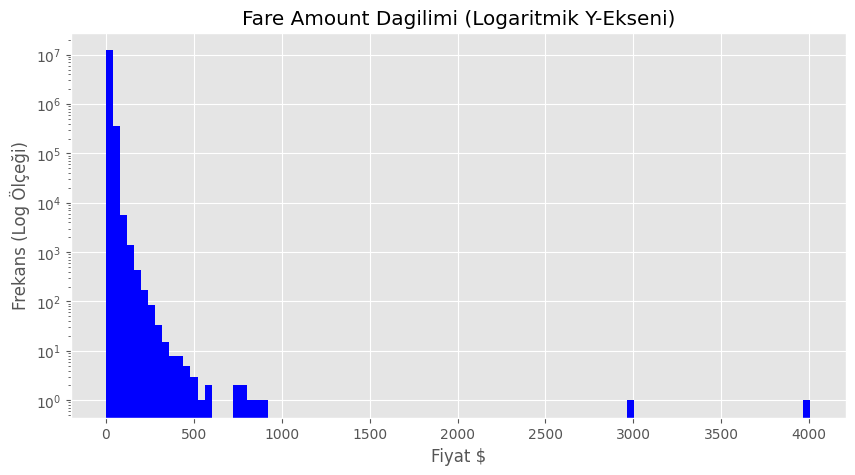

In [42]:
# Logaritmic histogram
plt.figure(figsize=(10, 5))
plt.hist(df['fare_amount'], bins=100, color='blue')
plt.yscale('log') # Y eksenini logaritmik yapar
plt.title('Fare Amount Dagilimi (Logaritmik Y-Ekseni)')
plt.xlabel('Fiyat $')
plt.ylabel('Frekans (Log Ölçeği)')
plt.show()

#! Aşağıdaki grafik elimizdeki verinin skew dağılımını göstermektedir.

In [43]:
df[df["fare_amount"] > 100]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,advanced_zscore_for_trip_distance,fare_amount_normalize,fare_per_distance
2592,2015-01-01 00:20:57,2015-01-01 00:24:59,3,2.80,5,223,74,3,120.0,0.0,0.0,0.00,5.33,0.0,125.63,24.956500,4.795791,42.857143
10676,2015-01-01 00:36:39,2015-01-01 00:37:00,1,1.50,5,162,162,1,209.0,0.0,0.0,41.85,0.00,0.0,251.15,44.966667,5.347108,139.333333
13153,2015-01-01 00:18:04,2015-01-01 00:55:56,3,18.75,5,48,265,2,120.0,0.0,0.0,0.00,0.00,0.3,120.30,24.956500,4.795791,6.400000
15515,2015-01-01 00:50:08,2015-01-01 01:25:54,2,27.96,5,68,265,1,137.0,0.0,0.5,29.60,11.00,0.3,178.40,28.778667,4.927254,4.899857
16978,2015-01-01 00:26:43,2015-01-01 00:34:29,3,2.67,5,68,265,2,120.0,0.0,0.5,0.00,11.75,0.3,132.55,24.956500,4.795791,44.943820
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12695967,2015-01-31 22:25:06,2015-01-31 22:58:32,1,25.70,4,132,132,1,120.5,0.5,0.5,24.36,0.00,0.3,146.16,25.068917,4.799914,4.688716
12709257,2015-01-31 22:49:14,2015-01-31 22:49:34,1,17.70,5,265,265,1,102.0,0.0,0.0,20.45,0.00,0.3,122.75,20.909500,4.634729,5.762712
12728578,2015-01-31 23:33:04,2015-02-01 01:09:52,1,34.90,1,230,187,2,104.0,0.5,0.5,0.00,10.66,0.3,115.96,21.359167,4.653960,2.979943
12739292,2015-01-31 23:55:19,2015-02-01 00:51:27,1,29.10,5,100,265,1,125.0,0.0,0.0,31.32,0.00,0.3,156.62,26.080667,4.836282,4.295533


In [44]:
indexes = df[df["trip_distance"] <= 0].index
df.drop(index=indexes, inplace=True)

In [45]:
df["fare_per_distance"] = df["fare_amount"] / df["trip_distance"]
df

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,advanced_zscore_for_trip_distance,fare_amount_normalize,fare_per_distance
0,2015-01-01 00:11:33,2015-01-01 00:16:48,1,1.0,1,41,166,1,5.7,0.5,0.5,1.40,0.0,0.0,8.40,0.741950,1.902108,5.700000
1,2015-01-01 00:18:24,2015-01-01 00:24:20,1,0.9,1,166,238,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,0.674500,1.945910,6.666667
2,2015-01-01 00:26:19,2015-01-01 00:41:06,1,3.5,1,238,162,1,13.2,0.5,0.5,2.90,0.0,0.0,17.40,0.944300,2.653242,3.771429
3,2015-01-01 00:45:26,2015-01-01 00:53:20,1,2.1,1,162,263,1,8.2,0.5,0.5,2.37,0.0,0.0,11.87,0.179867,2.219203,3.904762
4,2015-01-01 00:59:21,2015-01-01 01:05:24,1,1.0,1,236,141,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,0.674500,1.945910,6.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12741030,2015-01-31 23:21:42,2015-01-31 23:31:00,1,1.6,1,90,249,1,8.0,0.5,0.5,2.32,0.0,0.3,11.62,0.224833,2.197225,5.000000
12741031,2015-01-31 23:42:43,2015-01-31 23:49:32,1,0.6,1,90,68,1,6.0,0.5,0.5,1.46,0.0,0.3,8.76,0.674500,1.945910,10.000000
12741032,2015-01-31 23:55:16,2015-02-01 00:16:45,1,3.0,1,68,148,1,15.0,0.5,0.5,4.07,0.0,0.3,20.37,1.349000,2.772589,5.000000
12741033,2015-01-31 23:20:53,2015-02-01 00:07:35,1,6.9,1,189,237,1,32.5,0.5,0.5,6.00,0.0,0.3,39.80,5.283583,3.511545,4.710145


In [46]:
df["fare_per_distance"].max()

np.float64(27500.0)

In [47]:
df["fare_per_distance"].min()   #!

np.float64(2.0272790671272644e-07)

In [50]:
df["fare_per_distance"].quantile(0.999)

np.float64(62.5)

In [51]:
df[df["fare_per_distance"] > 70]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,advanced_zscore_for_trip_distance,fare_amount_normalize,fare_per_distance
2228,2015-01-01 00:07:48,2015-01-01 00:09:21,2,0.04,1,79,79,2,3.0,0.5,0.5,0.00,0.0,0.3,4.30,1.349000,1.386294,75.000000
3288,2015-01-01 00:13:09,2015-01-01 00:13:19,1,0.02,1,151,264,2,2.5,0.5,0.5,0.00,0.0,0.3,3.80,1.461417,1.252763,125.000000
3304,2015-01-01 00:26:48,2015-01-01 00:27:21,2,0.30,5,262,262,1,76.0,0.0,0.5,11.52,0.0,0.3,88.32,15.063833,4.343805,253.333333
4001,2015-01-01 00:38:48,2015-01-01 00:39:13,1,0.03,1,142,142,2,2.5,0.5,0.5,0.00,0.0,0.3,3.80,1.461417,1.252763,83.333333
4436,2015-01-01 00:19:28,2015-01-01 00:20:25,1,0.03,1,79,79,2,2.5,0.5,0.5,0.00,0.0,0.3,3.80,1.461417,1.252763,83.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12737568,2015-01-31 23:30:43,2015-01-31 23:31:49,2,0.01,1,249,249,2,3.0,0.5,0.5,0.00,0.0,0.3,4.30,1.349000,1.386294,300.000000
12739797,2015-01-31 23:07:36,2015-01-31 23:07:48,2,0.01,1,48,264,2,2.5,0.5,0.5,0.00,0.0,0.3,3.80,1.461417,1.252763,250.000000
12740641,2015-01-31 23:11:31,2015-01-31 23:12:07,5,0.03,1,229,229,2,2.5,0.5,0.5,0.00,0.0,0.3,3.80,1.461417,1.252763,83.333333
12740966,2015-01-31 23:10:01,2015-01-31 23:10:32,1,0.05,2,264,264,2,52.0,0.0,0.5,0.00,0.0,0.3,52.80,9.667833,3.970292,1040.000000


- değeri 100 den fazla olduğu halde normal olan fare_amount var mı?

In [52]:
df[(df["fare_amount"] > 100) & (df["fare_per_distance"] < 70)]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,advanced_zscore_for_trip_distance,fare_amount_normalize,fare_per_distance
2592,2015-01-01 00:20:57,2015-01-01 00:24:59,3,2.80,5,223,74,3,120.00,0.0,0.0,0.00,5.33,0.0,125.63,24.956500,4.795791,42.857143
13153,2015-01-01 00:18:04,2015-01-01 00:55:56,3,18.75,5,48,265,2,120.00,0.0,0.0,0.00,0.00,0.3,120.30,24.956500,4.795791,6.400000
15515,2015-01-01 00:50:08,2015-01-01 01:25:54,2,27.96,5,68,265,1,137.00,0.0,0.5,29.60,11.00,0.3,178.40,28.778667,4.927254,4.899857
16978,2015-01-01 00:26:43,2015-01-01 00:34:29,3,2.67,5,68,265,2,120.00,0.0,0.5,0.00,11.75,0.3,132.55,24.956500,4.795791,44.943820
17969,2015-01-01 00:16:53,2015-01-01 00:59:30,2,23.07,5,138,265,1,133.33,0.0,0.0,26.67,0.00,0.3,160.30,27.953528,4.900299,5.779367
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12695967,2015-01-31 22:25:06,2015-01-31 22:58:32,1,25.70,4,132,132,1,120.50,0.5,0.5,24.36,0.00,0.3,146.16,25.068917,4.799914,4.688716
12709257,2015-01-31 22:49:14,2015-01-31 22:49:34,1,17.70,5,265,265,1,102.00,0.0,0.0,20.45,0.00,0.3,122.75,20.909500,4.634729,5.762712
12728578,2015-01-31 23:33:04,2015-02-01 01:09:52,1,34.90,1,230,187,2,104.00,0.5,0.5,0.00,10.66,0.3,115.96,21.359167,4.653960,2.979943
12739292,2015-01-31 23:55:19,2015-02-01 00:51:27,1,29.10,5,100,265,1,125.00,0.0,0.0,31.32,0.00,0.3,156.62,26.080667,4.836282,4.295533


In [53]:
df[(df["fare_amount"] < 100) & (df["fare_per_distance"] < 70)]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,advanced_zscore_for_trip_distance,fare_amount_normalize,fare_per_distance
0,2015-01-01 00:11:33,2015-01-01 00:16:48,1,1.0,1,41,166,1,5.7,0.5,0.5,1.40,0.0,0.0,8.40,0.741950,1.902108,5.700000
1,2015-01-01 00:18:24,2015-01-01 00:24:20,1,0.9,1,166,238,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,0.674500,1.945910,6.666667
2,2015-01-01 00:26:19,2015-01-01 00:41:06,1,3.5,1,238,162,1,13.2,0.5,0.5,2.90,0.0,0.0,17.40,0.944300,2.653242,3.771429
3,2015-01-01 00:45:26,2015-01-01 00:53:20,1,2.1,1,162,263,1,8.2,0.5,0.5,2.37,0.0,0.0,11.87,0.179867,2.219203,3.904762
4,2015-01-01 00:59:21,2015-01-01 01:05:24,1,1.0,1,236,141,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,0.674500,1.945910,6.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12741030,2015-01-31 23:21:42,2015-01-31 23:31:00,1,1.6,1,90,249,1,8.0,0.5,0.5,2.32,0.0,0.3,11.62,0.224833,2.197225,5.000000
12741031,2015-01-31 23:42:43,2015-01-31 23:49:32,1,0.6,1,90,68,1,6.0,0.5,0.5,1.46,0.0,0.3,8.76,0.674500,1.945910,10.000000
12741032,2015-01-31 23:55:16,2015-02-01 00:16:45,1,3.0,1,68,148,1,15.0,0.5,0.5,4.07,0.0,0.3,20.37,1.349000,2.772589,5.000000
12741033,2015-01-31 23:20:53,2015-02-01 00:07:35,1,6.9,1,189,237,1,32.5,0.5,0.5,6.00,0.0,0.3,39.80,5.283583,3.511545,4.710145


In [54]:
indexes = df[(df["fare_amount"] > 100) & (df["fare_per_distance"] > 70)].index
df.drop(index=indexes, inplace=True)

In [55]:
df

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,advanced_zscore_for_trip_distance,fare_amount_normalize,fare_per_distance
0,2015-01-01 00:11:33,2015-01-01 00:16:48,1,1.0,1,41,166,1,5.7,0.5,0.5,1.40,0.0,0.0,8.40,0.741950,1.902108,5.700000
1,2015-01-01 00:18:24,2015-01-01 00:24:20,1,0.9,1,166,238,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,0.674500,1.945910,6.666667
2,2015-01-01 00:26:19,2015-01-01 00:41:06,1,3.5,1,238,162,1,13.2,0.5,0.5,2.90,0.0,0.0,17.40,0.944300,2.653242,3.771429
3,2015-01-01 00:45:26,2015-01-01 00:53:20,1,2.1,1,162,263,1,8.2,0.5,0.5,2.37,0.0,0.0,11.87,0.179867,2.219203,3.904762
4,2015-01-01 00:59:21,2015-01-01 01:05:24,1,1.0,1,236,141,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,0.674500,1.945910,6.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12741030,2015-01-31 23:21:42,2015-01-31 23:31:00,1,1.6,1,90,249,1,8.0,0.5,0.5,2.32,0.0,0.3,11.62,0.224833,2.197225,5.000000
12741031,2015-01-31 23:42:43,2015-01-31 23:49:32,1,0.6,1,90,68,1,6.0,0.5,0.5,1.46,0.0,0.3,8.76,0.674500,1.945910,10.000000
12741032,2015-01-31 23:55:16,2015-02-01 00:16:45,1,3.0,1,68,148,1,15.0,0.5,0.5,4.07,0.0,0.3,20.37,1.349000,2.772589,5.000000
12741033,2015-01-31 23:20:53,2015-02-01 00:07:35,1,6.9,1,189,237,1,32.5,0.5,0.5,6.00,0.0,0.3,39.80,5.283583,3.511545,4.710145


In [57]:
df.columns

Index(['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count',
       'trip_distance', 'RatecodeID', 'PULocationID', 'DOLocationID',
       'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount',
       'tolls_amount', 'improvement_surcharge', 'total_amount',
       'advanced_zscore_for_trip_distance', 'fare_amount_normalize',
       'fare_per_distance'],
      dtype='object')

In [58]:
df.drop(columns=["advanced_zscore_for_trip_distance", "fare_amount_normalize", "fare_per_distance"], inplace=True)

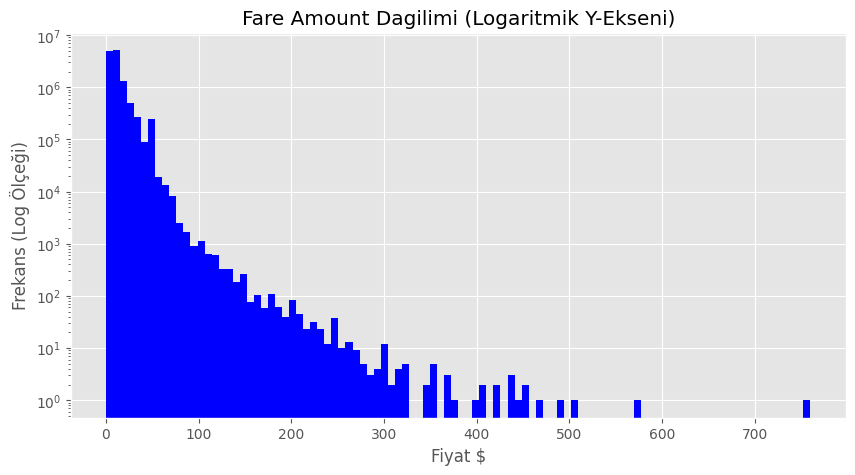

In [59]:
# Logaritmic histogram
plt.figure(figsize=(10, 5))
plt.hist(df['fare_amount'], bins=100, color='blue')
plt.yscale('log') # Y eksenini logaritmik yapar
plt.title('Fare Amount Dagilimi (Logaritmik Y-Ekseni)')
plt.xlabel('Fiyat $')
plt.ylabel('Frekans (Log Ölçeği)')
plt.show()

#! Aşağıdaki grafik elimizdeki verinin temizlendikten sonraki halini göstermektedir.

Bu temizlenmiş yeni hali inceleyelim

In [60]:
df["fare_amount"].max()

np.float64(760.01)

In [61]:
df[df["fare_amount"] > 400]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
1202886,2015-01-04 05:40:11,2015-01-04 05:55:00,3,8.70,5,138,216,2,405.00,0.0,0.0,0.0,0.00,0.0,405.30
1258952,2015-01-04 11:09:41,2015-01-04 12:16:19,1,52.11,5,161,265,1,440.00,0.0,0.0,59.0,0.00,0.3,499.30
1260451,2015-01-04 11:11:03,2015-01-04 12:16:32,1,51.42,5,161,265,1,448.00,0.0,0.0,50.0,0.00,0.0,498.00
1943898,2015-01-06 10:26:25,2015-01-06 11:47:49,1,69.09,5,132,265,1,420.00,0.0,0.0,33.0,0.00,0.3,453.30
3626812,2015-01-10 05:17:04,2015-01-10 07:58:48,1,99.89,4,162,265,2,503.50,0.5,0.5,0.0,0.00,0.3,504.80
5192918,2015-01-13 19:42:12,2015-01-13 21:59:41,1,99.90,5,132,265,1,570.08,0.0,0.0,20.0,0.00,0.3,590.38
5495781,2015-01-14 12:01:10,2015-01-14 14:28:22,2,99.90,5,215,265,1,450.00,0.0,0.0,0.0,0.00,0.3,450.30
7744382,2015-01-19 14:00:19,2015-01-19 15:17:05,1,74.40,4,132,265,2,410.00,0.0,0.5,0.0,6.83,0.3,417.63
8470138,2015-01-21 10:49:17,2015-01-21 13:48:26,3,99.90,5,132,265,1,425.00,0.0,0.0,0.0,0.00,0.3,425.30
9367943,2015-01-23 10:34:58,2015-01-23 11:42:13,1,15.09,5,48,242,2,467.54,0.0,0.5,0.0,0.00,0.3,468.34


In [ ]:
df["fare_amount"].min() #!

np.float64(0.01)

In [ ]:
df[df["fare_amount"] < 1]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
12211,2015-01-01 00:17:37,2015-01-01 00:24:49,1,1.66,5,83,83,2,0.01,0.0,0.5,0.0,0.00,0.3,0.81
16829,2015-01-01 00:41:30,2015-01-01 00:42:27,3,7.00,5,17,17,2,0.03,0.0,0.0,0.0,0.00,0.3,0.33
25073,2015-01-01 00:04:23,2015-01-01 00:06:09,1,0.40,5,265,265,2,0.01,0.0,0.0,0.0,0.00,0.0,0.31
26510,2015-01-01 00:06:40,2015-01-01 00:27:12,1,1.60,5,161,143,2,0.01,0.0,0.0,0.0,0.00,0.0,0.31
28207,2015-01-01 00:01:36,2015-01-01 00:29:26,4,18.50,5,132,113,3,0.01,0.0,0.0,0.0,5.33,0.0,5.64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12393944,2015-01-31 11:31:08,2015-01-31 11:55:08,3,4.10,5,262,263,3,0.01,0.0,0.0,0.0,0.00,0.3,0.31
12545820,2015-01-31 17:51:30,2015-01-31 17:53:14,1,0.30,5,236,236,4,0.01,0.0,0.0,0.0,0.00,0.3,0.31
12696381,2015-01-31 22:33:49,2015-01-31 22:44:36,1,2.50,5,125,265,1,0.60,0.0,0.0,65.0,0.00,0.3,65.90
12729769,2015-01-31 23:51:09,2015-02-01 00:45:58,1,32.10,5,246,143,3,0.01,0.0,0.0,0.0,2.44,0.3,2.75


In [66]:
indexes = df[df["passenger_count"] <= 0].index
df.drop(index=indexes, inplace=True)

In [67]:
df[df["fare_amount"] < 0.1]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
12211,2015-01-01 00:17:37,2015-01-01 00:24:49,1,1.66,5,83,83,2,0.01,0.0,0.5,0.0,0.00,0.3,0.81
16829,2015-01-01 00:41:30,2015-01-01 00:42:27,3,7.00,5,17,17,2,0.03,0.0,0.0,0.0,0.00,0.3,0.33
25073,2015-01-01 00:04:23,2015-01-01 00:06:09,1,0.40,5,265,265,2,0.01,0.0,0.0,0.0,0.00,0.0,0.31
26510,2015-01-01 00:06:40,2015-01-01 00:27:12,1,1.60,5,161,143,2,0.01,0.0,0.0,0.0,0.00,0.0,0.31
28207,2015-01-01 00:01:36,2015-01-01 00:29:26,4,18.50,5,132,113,3,0.01,0.0,0.0,0.0,5.33,0.0,5.64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12315612,2015-01-31 05:03:51,2015-01-31 05:04:34,1,0.76,5,265,265,2,0.01,0.0,0.0,0.0,28.00,0.3,28.31
12316457,2015-01-31 05:06:14,2015-01-31 05:15:09,1,0.70,5,201,201,3,0.01,0.0,0.0,0.0,0.00,0.3,0.31
12393944,2015-01-31 11:31:08,2015-01-31 11:55:08,3,4.10,5,262,263,3,0.01,0.0,0.0,0.0,0.00,0.3,0.31
12545820,2015-01-31 17:51:30,2015-01-31 17:53:14,1,0.30,5,236,236,4,0.01,0.0,0.0,0.0,0.00,0.3,0.31


In [73]:
df[df["fare_amount"] < 1]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
12211,2015-01-01 00:17:37,2015-01-01 00:24:49,1,1.66,5,83,83,2,0.01,0.0,0.5,0.0,0.00,0.3,0.81
16829,2015-01-01 00:41:30,2015-01-01 00:42:27,3,7.00,5,17,17,2,0.03,0.0,0.0,0.0,0.00,0.3,0.33
25073,2015-01-01 00:04:23,2015-01-01 00:06:09,1,0.40,5,265,265,2,0.01,0.0,0.0,0.0,0.00,0.0,0.31
26510,2015-01-01 00:06:40,2015-01-01 00:27:12,1,1.60,5,161,143,2,0.01,0.0,0.0,0.0,0.00,0.0,0.31
28207,2015-01-01 00:01:36,2015-01-01 00:29:26,4,18.50,5,132,113,3,0.01,0.0,0.0,0.0,5.33,0.0,5.64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12316457,2015-01-31 05:06:14,2015-01-31 05:15:09,1,0.70,5,201,201,3,0.01,0.0,0.0,0.0,0.00,0.3,0.31
12393944,2015-01-31 11:31:08,2015-01-31 11:55:08,3,4.10,5,262,263,3,0.01,0.0,0.0,0.0,0.00,0.3,0.31
12545820,2015-01-31 17:51:30,2015-01-31 17:53:14,1,0.30,5,236,236,4,0.01,0.0,0.0,0.0,0.00,0.3,0.31
12696381,2015-01-31 22:33:49,2015-01-31 22:44:36,1,2.50,5,125,265,1,0.60,0.0,0.0,65.0,0.00,0.3,65.90


In [74]:
indexes = df[df["fare_amount"] < 1].index
df.drop(index=indexes, inplace=True)

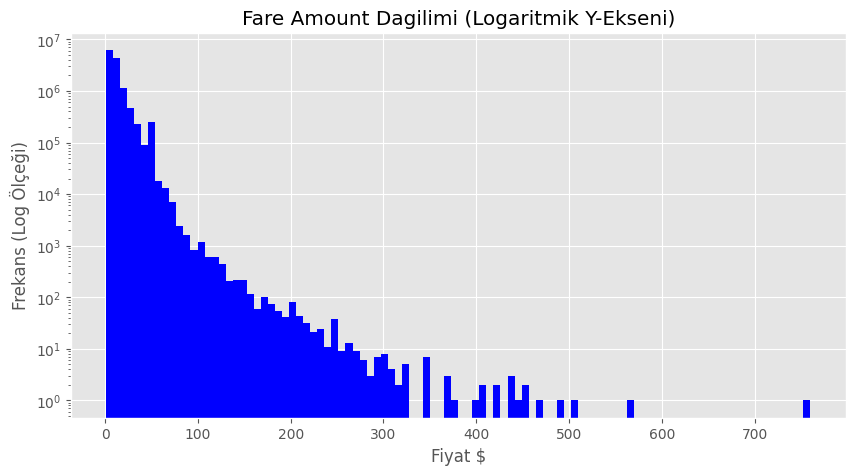

In [75]:
# Logaritmic histogram
plt.figure(figsize=(10, 5))
plt.hist(df['fare_amount'], bins=100, color='blue')
plt.yscale('log') # Y eksenini logaritmik yapar
plt.title('Fare Amount Dagilimi (Logaritmik Y-Ekseni)')
plt.xlabel('Fiyat $')
plt.ylabel('Frekans (Log Ölçeği)')
plt.show()

#! Aşağıdaki grafik elimizdeki verinin temizlendikten sonraki halini göstermektedir.

In [76]:
df[df["fare_amount"] > 700]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
11865623,2015-01-30 10:42:15,2015-01-30 11:08:51,1,16.7,5,263,265,3,760.01,0.0,0.0,0.0,0.0,0.3,760.31


In [77]:
df[df["fare_amount"] > 400]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
1202886,2015-01-04 05:40:11,2015-01-04 05:55:00,3,8.70,5,138,216,2,405.00,0.0,0.0,0.0,0.00,0.0,405.30
1258952,2015-01-04 11:09:41,2015-01-04 12:16:19,1,52.11,5,161,265,1,440.00,0.0,0.0,59.0,0.00,0.3,499.30
1260451,2015-01-04 11:11:03,2015-01-04 12:16:32,1,51.42,5,161,265,1,448.00,0.0,0.0,50.0,0.00,0.0,498.00
1943898,2015-01-06 10:26:25,2015-01-06 11:47:49,1,69.09,5,132,265,1,420.00,0.0,0.0,33.0,0.00,0.3,453.30
3626812,2015-01-10 05:17:04,2015-01-10 07:58:48,1,99.89,4,162,265,2,503.50,0.5,0.5,0.0,0.00,0.3,504.80
5192918,2015-01-13 19:42:12,2015-01-13 21:59:41,1,99.90,5,132,265,1,570.08,0.0,0.0,20.0,0.00,0.3,590.38
5495781,2015-01-14 12:01:10,2015-01-14 14:28:22,2,99.90,5,215,265,1,450.00,0.0,0.0,0.0,0.00,0.3,450.30
7744382,2015-01-19 14:00:19,2015-01-19 15:17:05,1,74.40,4,132,265,2,410.00,0.0,0.5,0.0,6.83,0.3,417.63
8470138,2015-01-21 10:49:17,2015-01-21 13:48:26,3,99.90,5,132,265,1,425.00,0.0,0.0,0.0,0.00,0.3,425.30
9367943,2015-01-23 10:34:58,2015-01-23 11:42:13,1,15.09,5,48,242,2,467.54,0.0,0.5,0.0,0.00,0.3,468.34


In [78]:
indexes = df[(df["fare_amount"] > 400) & (df["trip_distance"] < 20)].index
df.drop(index=indexes, inplace=True)

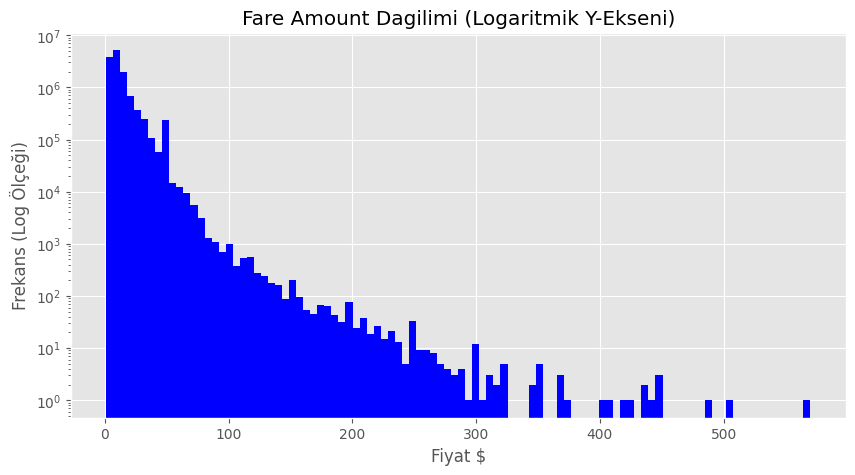

In [79]:
# Logaritmic histogram
plt.figure(figsize=(10, 5))
plt.hist(df['fare_amount'], bins=100, color='blue')
plt.yscale('log') # Y eksenini logaritmik yapar
plt.title('Fare Amount Dagilimi (Logaritmik Y-Ekseni)')
plt.xlabel('Fiyat $')
plt.ylabel('Frekans (Log Ölçeği)')
plt.show()

#! Aşağıdaki grafik elimizdeki verinin temizlendikten sonraki halini göstermektedir.

Sonuç: fare_amount son haline getirildi!